In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface
from tqdm import tqdm
import os


In [2]:
recording = []
for date in ['20240112']:#, '20240115']:
    recording.append(se.read_blackrock(f'/media/ubuntu/sda/Monkey/TVSD/monkeyF/{date}/Block_1/Hub2-instance1_B001.ns6'))

In [3]:
recording_full = si.concatenate_recordings(recording)

In [4]:
from probeinterface import write_probeinterface, read_probeinterface
probe_30channel = read_probeinterface('/media/ubuntu/sda/Monkey/scripts/sua/probe_256.json')
probe_30channel.set_global_device_channel_indices([i for i in range(256)])
recording_recorded = recording_full.set_probegroup(probe_30channel)

In [5]:
recording_cmr = recording_recorded
recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
print(recording_f)
recording_cmr = spre.common_reference(recording_f, reference="global", operator="median")
print(recording_cmr)

BandpassFilterRecording: 256 channels - 30.0kHz - 1 segments - 37,477,862 samples 
                         1,249.26s (20.82 minutes) - int16 dtype - 17.87 GiB
CommonReferenceRecording: 256 channels - 30.0kHz - 1 segments - 37,477,862 samples 
                          1,249.26s (20.82 minutes) - int16 dtype - 17.87 GiB


In [6]:
recording_preprocessed = recording_cmr.save(format="binary")
print(recording_preprocessed)


Use cache_folder=/tmp/spikeinterface_cache/tmpe2hehero/0SH13EXV
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=14.65 MiB - total_memory=14.65 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/1250 [00:00<?, ?it/s]

BinaryFolderRecording: 256 channels - 30.0kHz - 1 segments - 37,477,862 samples 
                       1,249.26s (20.82 minutes) - int16 dtype - 17.87 GiB


In [7]:
os.makedirs(f"/media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub2_instance1_day1", exist_ok=True)
output_folder = f"/media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub2_instance1_day1"
sorting_kilosort4 = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder=output_folder + "/kilosort4")
analyzer_kilosort4 = si.create_sorting_analyzer(sorting=sorting_kilosort4, recording=recording_preprocessed, format='binary_folder', folder=output_folder + '/analyzer_kilosort4_binary')

extensions_to_compute = [
            "random_spikes",
            "waveforms",
            "noise_levels",
            "templates",
            "spike_amplitudes",
            "unit_locations",
            "spike_locations",
            "correlograms",
            "template_similarity"
        ]

extension_params = {
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_kilosort4.compute(extensions_to_compute, extension_params=extension_params)

qm_params = sqm.get_default_qm_params()
analyzer_kilosort4.compute("quality_metrics", qm_params)

import spikeinterface.exporters as sexp
sexp.export_to_phy(analyzer_kilosort4, output_folder + "/phy_folder_for_kilosort", verbose=True)

100%|██████████| 16/16 [15:08<00:00, 56.79s/it]


estimate_sparsity (no parallelization):   0%|          | 0/1250 [00:00<?, ?it/s]

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/spikeinterface/core/basesorting.py:380: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


compute_waveforms (no parallelization):   0%|          | 0/1250 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

...

write_binary_recording (no parallelization):   0%|          | 0/1250 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/254 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/254 [00:00<?, ?it/s]

extract PCs (no parallelization):   0%|          | 0/1250 [00:00<?, ?it/s]

Run:
phy template-gui  /media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub2_instance1_day1/phy_folder_for_kilosort/params.py


In [8]:
recording = []
for date in ['20240112']:#, '20240115']:
    recording.append(se.read_blackrock(f'/media/ubuntu/sda/Monkey/TVSD/monkeyF/{date}/Block_2/Hub2-instance1_B002.ns6'))

recording_full = si.concatenate_recordings(recording)
from probeinterface import write_probeinterface, read_probeinterface
probe_30channel = read_probeinterface('/media/ubuntu/sda/Monkey/scripts/sua/probe_256.json')
probe_30channel.set_global_device_channel_indices([i for i in range(256)])
recording_recorded = recording_full.set_probegroup(probe_30channel)
recording_cmr = recording_recorded
recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
print(recording_f)
recording_cmr = spre.common_reference(recording_f, reference="global", operator="median")
print(recording_cmr)

recording_preprocessed = recording_cmr.save(format="binary")
print(recording_preprocessed)

os.makedirs(f"/media/ubuntu/sda/Monkey/data/sorted/Block_2_Hub2_instance1_day1", exist_ok=True)
output_folder = f"/media/ubuntu/sda/Monkey/data/sorted/Block_2_Hub2_instance1_day1"
sorting_kilosort4 = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder=output_folder + "/kilosort4")
analyzer_kilosort4 = si.create_sorting_analyzer(sorting=sorting_kilosort4, recording=recording_preprocessed, format='binary_folder', folder=output_folder + '/analyzer_kilosort4_binary')

extensions_to_compute = [
            "random_spikes",
            "waveforms",
            "noise_levels",
            "templates",
            "spike_amplitudes",
            "unit_locations",
            "spike_locations",
            "correlograms",
            "template_similarity"
        ]

extension_params = {
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_kilosort4.compute(extensions_to_compute, extension_params=extension_params)

qm_params = sqm.get_default_qm_params()
analyzer_kilosort4.compute("quality_metrics", qm_params)

import spikeinterface.exporters as sexp
sexp.export_to_phy(analyzer_kilosort4, output_folder + "/phy_folder_for_kilosort", verbose=True)

BandpassFilterRecording: 256 channels - 30.0kHz - 1 segments - 31,636,084 samples 
                         1,054.54s (17.58 minutes) - int16 dtype - 15.09 GiB
CommonReferenceRecording: 256 channels - 30.0kHz - 1 segments - 31,636,084 samples 
                          1,054.54s (17.58 minutes) - int16 dtype - 15.09 GiB
Use cache_folder=/tmp/spikeinterface_cache/tmprxd29yrb/YDW0R6GB
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=14.65 MiB - total_memory=14.65 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/1055 [00:00<?, ?it/s]

BinaryFolderRecording: 256 channels - 30.0kHz - 1 segments - 31,636,084 samples 
                       1,054.54s (17.58 minutes) - int16 dtype - 15.09 GiB


100%|██████████| 16/16 [19:36<00:00, 73.51s/it]


estimate_sparsity (no parallelization):   0%|          | 0/1055 [00:00<?, ?it/s]

...

write_binary_recording (no parallelization):   0%|          | 0/1055 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/258 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/258 [00:00<?, ?it/s]

extract PCs (no parallelization):   0%|          | 0/1055 [00:00<?, ?it/s]

Run:
phy template-gui  /media/ubuntu/sda/Monkey/data/sorted/Block_2_Hub2_instance1_day1/phy_folder_for_kilosort/params.py


In [2]:
recording = []
for date in ['20240112']:#, '20240115']:
    recording.append(se.read_blackrock(f'/media/ubuntu/sda/Monkey/TVSD/monkeyF/{date}/Block_4/Hub2-instance1_B004.ns6'))

recording_full = si.concatenate_recordings(recording)
from probeinterface import write_probeinterface, read_probeinterface
probe_30channel = read_probeinterface('/media/ubuntu/sda/Monkey/scripts/sua/probe_256.json')
probe_30channel.set_global_device_channel_indices([i for i in range(256)])
recording_recorded = recording_full.set_probegroup(probe_30channel)
recording_cmr = recording_recorded
recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
print(recording_f)
recording_cmr = spre.common_reference(recording_f, reference="global", operator="median")
print(recording_cmr)

recording_preprocessed = recording_cmr.save(format="binary")
print(recording_preprocessed)

os.makedirs(f"/media/ubuntu/sda/Monkey/data/sorted/Block_4_Hub2_instance1_day1", exist_ok=True)
output_folder = f"/media/ubuntu/sda/Monkey/data/sorted/Block_4_Hub2_instance1_day1"
sorting_kilosort4 = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder=output_folder + "/kilosort4")
analyzer_kilosort4 = si.create_sorting_analyzer(sorting=sorting_kilosort4, recording=recording_preprocessed, format='binary_folder', folder=output_folder + '/analyzer_kilosort4_binary')

extensions_to_compute = [
            "random_spikes",
            "waveforms",
            "noise_levels",
            "templates",
            "spike_amplitudes",
            "unit_locations",
            "spike_locations",
            "correlograms",
            "template_similarity"
        ]

extension_params = {
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_kilosort4.compute(extensions_to_compute, extension_params=extension_params)

qm_params = sqm.get_default_qm_params()
analyzer_kilosort4.compute("quality_metrics", qm_params)

import spikeinterface.exporters as sexp
sexp.export_to_phy(analyzer_kilosort4, output_folder + "/phy_folder_for_kilosort", verbose=True)

BandpassFilterRecording: 256 channels - 30.0kHz - 1 segments - 26,402,760 samples 
                         880.09s (14.67 minutes) - int16 dtype - 12.59 GiB
CommonReferenceRecording: 256 channels - 30.0kHz - 1 segments - 26,402,760 samples 
                          880.09s (14.67 minutes) - int16 dtype - 12.59 GiB
Use cache_folder=/tmp/spikeinterface_cache/tmpexr_m6sx/E18KH2VP
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=14.65 MiB - total_memory=14.65 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/881 [00:00<?, ?it/s]

BinaryFolderRecording: 256 channels - 30.0kHz - 1 segments - 26,402,760 samples 
                       880.09s (14.67 minutes) - int16 dtype - 12.59 GiB


100%|██████████| 16/16 [10:54<00:00, 40.92s/it]


estimate_sparsity (no parallelization):   0%|          | 0/881 [00:00<?, ?it/s]

...

write_binary_recording (no parallelization):   0%|          | 0/881 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/272 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/272 [00:00<?, ?it/s]

extract PCs (no parallelization):   0%|          | 0/881 [00:00<?, ?it/s]

Run:
phy template-gui  /media/ubuntu/sda/Monkey/data/sorted/Block_4_Hub2_instance1_day1/phy_folder_for_kilosort/params.py


In [5]:
import os
import re
import glob
import numpy as np
import pandas as pd
import numpy as np
import scipy.io as sio
import spikeinterface.extractors as se
import spikeinterface as si
import spikeinterface.sorters as ss
import spikeinterface.postprocessing as spost
import spikeinterface.qualitymetrics as sqm
from pathlib import Path
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

from typing import List, Tuple


ROOT_SORT_DIR = "/media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub1_instance2_day1/phy_folder_for_kilosort"

# 需要的 cluster 指标文件（来自 phy_folder_for_kilosort）
CLUSTER_INFO_FILENAME = "cluster_info.tsv"

SPIKE_CLUSTERS_FILENAME = "spike_clusters.npy"
SPIKE_TIMES_FILENAME = "spike_times.npy"

In [19]:
def load_cluster_info(phy_dir: str) -> pd.DataFrame:
    """读取 phy_folder_for_kilosort/cluster_info.tsv 为 DataFrame。
    该表包含所有需要的 cluster 级指标。
    如果cluster_info.tsv不存在，则尝试从其他文件构建基本信息。
    同时计算并添加mean_waveform信息。
    """
    path = os.path.join(phy_dir, CLUSTER_INFO_FILENAME)
    
    if os.path.exists(path):
        df = pd.read_csv(path, sep='\t')
        # 标准化主键列名
        if 'cluster_id' not in df.columns:
            raise ValueError(f"{path} 中缺少 cluster_id 列")
    else:
        print(f"警告: {path} 不存在，尝试从其他文件构建cluster信息")
        
        # 尝试从cluster_group.tsv构建基本信息
        cluster_group_path = os.path.join(phy_dir, "cluster_group.tsv")
        if os.path.exists(cluster_group_path):
            df = pd.read_csv(cluster_group_path, sep='\t')
            if 'cluster_id' not in df.columns:
                raise ValueError(f"{cluster_group_path} 中缺少 cluster_id 列")
        else:
            # 如果都没有，从spike_clusters.npy中提取唯一的cluster_id
            spike_clusters_path = os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME)
            if os.path.exists(spike_clusters_path):
                spike_clusters = np.load(spike_clusters_path)
                unique_clusters = np.unique(spike_clusters)
                df = pd.DataFrame({
                    'cluster_id': unique_clusters,
                    'group': 'unsorted'  # 默认分组
                })
            else:
                raise ValueError(f"无法找到任何cluster信息文件: {phy_dir}")
    
    # 计算mean_waveform并展开为多列添加到DataFrame
    mean_waveforms = compute_mean_waveform(phy_dir)
    if mean_waveforms:
        # 确定waveform的长度（通常是90个时间点）
        waveform_length = None
        for waveform in mean_waveforms.values():
            if waveform is not None:
                waveform_length = len(waveform)
                break
        
        if waveform_length is not None:
            # 创建waveform列名
            waveform_columns = [f'mean_waveform_{i}' for i in range(waveform_length)]
            
            # 为每个cluster创建waveform数据
            waveform_data = {}
            for cluster_id in df['cluster_id']:
                if cluster_id in mean_waveforms and mean_waveforms[cluster_id] is not None:
                    waveform = mean_waveforms[cluster_id]
                    # 确保waveform长度一致
                    if len(waveform) == waveform_length:
                        waveform_data[cluster_id] = waveform
                    else:
                        # 如果长度不匹配，用NaN填充或截断
                        padded_waveform = np.full(waveform_length, np.nan)
                        padded_waveform[:min(len(waveform), waveform_length)] = waveform[:min(len(waveform), waveform_length)]
                        waveform_data[cluster_id] = padded_waveform
                else:
                    # 没有waveform数据的cluster用NaN填充
                    waveform_data[cluster_id] = np.full(waveform_length, np.nan)
            
            # 将waveform数据转换为DataFrame并合并
            waveform_df = pd.DataFrame.from_dict(waveform_data, orient='index', columns=waveform_columns)
            waveform_df.index.name = 'cluster_id'
            waveform_df = waveform_df.reset_index()
            
            # 合并到主DataFrame
            df = df.merge(waveform_df, on='cluster_id', how='left')
            print(f"成功添加mean_waveform信息到 {len(mean_waveforms)} 个clusters，展开为 {waveform_length} 列")
        else:
            print("警告: 无法确定waveform长度")
    else:
        print("警告: 无法计算mean_waveform信息")
    
    return df


def load_spike_level(phy_dir: str) -> pd.DataFrame:
    """读取 spike 层面的 numpy 文件并返回 DataFrame: [cluster, time]
    time 使用原始采样点，不做单位转换。
    """
    spike_clusters = np.load(os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME))
    spike_times = np.load(os.path.join(phy_dir, SPIKE_TIMES_FILENAME))
    # 展平为一维
    spike_clusters = np.asarray(spike_clusters).reshape(-1)
    spike_times = np.asarray(spike_times).reshape(-1)
    if spike_clusters.shape[0] != spike_times.shape[0]:
        raise ValueError(f"spike_clusters 与 spike_times 行数不一致: {phy_dir}")
    df = pd.DataFrame({
        'cluster_id': spike_clusters.astype(int),
        'time': spike_times.astype(int),
    })
    return df


def compute_mean_waveform(phy_dir: str) -> dict:
    """计算每个cluster的平均波形
    
    Returns:
        dict: {cluster_id: mean_waveform_array}
    """
    templates_path = os.path.join(phy_dir, "templates.npy")
    spike_templates_path = os.path.join(phy_dir, "spike_templates.npy")
    spike_clusters_path = os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME)
    
    if not all(os.path.exists(p) for p in [templates_path, spike_templates_path, spike_clusters_path]):
        print("警告: 缺少计算waveform所需的文件，跳过mean_waveform计算")
        return {}
    
    # 加载数据
    templates = np.load(templates_path)  # shape: (n_templates, n_timepoints, n_channels)
    spike_templates = np.load(spike_templates_path).flatten()  # shape: (n_spikes,)
    spike_clusters = np.load(spike_clusters_path).flatten()  # shape: (n_spikes,)
    
    # 创建cluster到template的映射
    cluster_template_map = {}
    for spike_idx, (cluster_id, template_id) in enumerate(zip(spike_clusters, spike_templates)):
        if cluster_id not in cluster_template_map:
            cluster_template_map[cluster_id] = template_id
    
    # 计算每个cluster的mean_waveform
    mean_waveforms = {}
    for cluster_id, template_id in cluster_template_map.items():
        if template_id < templates.shape[0]:
            # 获取该cluster对应的template
            template = templates[template_id]  # shape: (n_timepoints, n_channels)
            # 如果模板是2D的，取第一个通道或平均所有通道
            if template.ndim == 2:
                if template.shape[1] == 1:
                    # 只有一个通道
                    mean_waveform = template[:, 0]
                else:
                    # 多个通道，取平均
                    mean_waveform = np.mean(template, axis=1)
            else:
                # 1D情况
                mean_waveform = template
            mean_waveforms[cluster_id] = mean_waveform
    
    return mean_waveforms

In [29]:
# 加载4个session的cluster信息（全部使用Hub1_instance2）
SESSION_PHY_DIRS = {
    1: "/media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub1_instance2_day1/phy_folder_for_kilosort",
    2: "/media/ubuntu/sda/Monkey/data/sorted/Block_2_Hub1_instance2_day1/phy_folder_for_kilosort",
    3: "/media/ubuntu/sda/Monkey/data/sorted/Block_3_Hub1_instance2_day1/phy_folder_for_kilosort",
    4: "/media/ubuntu/sda/Monkey/data/sorted/Block_4_Hub1_instance2_day1/phy_folder_for_kilosort",
}

cluster_inf_by_session = {}
for session_id, phy_dir in SESSION_PHY_DIRS.items():
    df = load_cluster_info(phy_dir=phy_dir)
    df = df[df["group"] == "good"].copy()
    df["date"] = session_id
    cluster_inf_by_session[session_id] = df
    wave_cols = [c for c in df.columns if c.startswith("mean_waveform_")]
    print(f"Session {session_id}: loaded {len(df)} good clusters from {phy_dir} (waveform cols: {len(wave_cols)})")

# 统一所有session的waveform列，缺失的补NaN，额外的删除
base_waveform_cols = [c for c in cluster_inf_by_session[1].columns if c.startswith("mean_waveform_")]
for session_id, df in cluster_inf_by_session.items():
    missing_cols = [c for c in base_waveform_cols if c not in df.columns]
    for col in missing_cols:
        df[col] = np.nan
    extra_cols = [c for c in df.columns if c.startswith("mean_waveform_") and c not in base_waveform_cols]
    if extra_cols:
        df = df.drop(columns=extra_cols)
    # 保持列顺序：非waveform列在前，waveform列在后
    non_waveform_cols = [c for c in df.columns if not c.startswith("mean_waveform_")]
    cluster_inf_by_session[session_id] = df[non_waveform_cols + base_waveform_cols]

成功添加mean_waveform信息到 280 个clusters，展开为 90 列
Session 1: loaded 60 good clusters from /media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub1_instance2_day1/phy_folder_for_kilosort (waveform cols: 90)
成功添加mean_waveform信息到 220 个clusters，展开为 90 列
Session 2: loaded 51 good clusters from /media/ubuntu/sda/Monkey/data/sorted/Block_2_Hub1_instance2_day1/phy_folder_for_kilosort (waveform cols: 90)
成功添加mean_waveform信息到 237 个clusters，展开为 90 列
Session 3: loaded 62 good clusters from /media/ubuntu/sda/Monkey/data/sorted/Block_3_Hub1_instance2_day1/phy_folder_for_kilosort (waveform cols: 90)
成功添加mean_waveform信息到 323 个clusters，展开为 90 列
Session 4: loaded 64 good clusters from /media/ubuntu/sda/Monkey/data/sorted/Block_4_Hub1_instance2_day1/phy_folder_for_kilosort (waveform cols: 90)


In [33]:
cluster_inf_by_session[1].shape

(60, 122)

In [34]:
from scipy.stats import pearsonr


def match_sessions_to_reference(cluster_inf_by_session, ref_session=1, corr_threshold=0.95):
    """将多个session分别与参考session匹配（按channel + waveform相关性）。
    只给参考session分配初始neuron ID，其它session匹配到参考session的沿用相同的neuron ID，未匹配的独立编号。
    返回合并后的cluster_inf_all以及匹配摘要。"""
    print(f"开始匹配，参考session: {ref_session}，相关性阈值: {corr_threshold}")

    waveform_cols = [col for col in cluster_inf_by_session[ref_session].columns if col.startswith("mean_waveform_")]
    ref_df = cluster_inf_by_session[ref_session].copy().reset_index(drop=True)
    ref_df["neuron"] = np.arange(len(ref_df))
    next_neuron_id = int(ref_df["neuron"].max()) + 1 if len(ref_df) else 0

    match_summary = {}
    match_records = []

    for session_id, df in cluster_inf_by_session.items():
        if session_id == ref_session:
            continue

        print(f"\n匹配 session {session_id} 到参考 session {ref_session} ...")
        tgt_df = df.copy().reset_index(drop=True)
        tgt_df["neuron"] = -1

        potential_matches = []
        for idx_ref, row_ref in tqdm(ref_df.iterrows(), total=len(ref_df), desc=f"ref vs session {session_id}"):
            wf_ref = row_ref[waveform_cols].values.astype(float)
            if np.isnan(wf_ref).all():
                continue

            candidates = tgt_df[tgt_df["ch"] == row_ref["ch"]]
            for idx_tgt, row_tgt in candidates.iterrows():
                wf_tgt = row_tgt[waveform_cols].values.astype(float)
                if np.isnan(wf_tgt).all():
                    continue

                valid_mask = ~(np.isnan(wf_ref) | np.isnan(wf_tgt))
                if valid_mask.sum() <= 10:
                    continue

                corr, _ = pearsonr(wf_ref[valid_mask], wf_tgt[valid_mask])
                if corr >= corr_threshold:
                    potential_matches.append({
                        "ref_idx": idx_ref,
                        "tgt_idx": idx_tgt,
                        "ref_cluster": row_ref["cluster_id"],
                        "tgt_cluster": row_tgt["cluster_id"],
                        "ch": row_ref["ch"],
                        "correlation": corr,
                        "session": session_id,
                    })

        potential_matches.sort(key=lambda x: x["correlation"], reverse=True)
        matched_ref = set()
        matched_tgt = set()

        for m in potential_matches:
            if m["ref_idx"] in matched_ref or m["tgt_idx"] in matched_tgt:
                continue

            tgt_df.loc[m["tgt_idx"], "neuron"] = int(ref_df.loc[m["ref_idx"], "neuron"])
            matched_ref.add(m["ref_idx"])
            matched_tgt.add(m["tgt_idx"])
            match_records.append({
                "session": session_id,
                "ref_cluster": m["ref_cluster"],
                "tgt_cluster": m["tgt_cluster"],
                "ch": m["ch"],
                "correlation": m["correlation"],
                "neuron_id": int(ref_df.loc[m["ref_idx"], "neuron"]),
            })

        # 未匹配目标补新ID
        for idx in range(len(tgt_df)):
            if tgt_df.loc[idx, "neuron"] == -1:
                tgt_df.loc[idx, "neuron"] = next_neuron_id
                next_neuron_id += 1

        cluster_inf_by_session[session_id] = tgt_df

        corrs = [r["correlation"] for r in match_records if r["session"] == session_id]
        match_summary[session_id] = {
            "matched_pairs": len(matched_tgt),
            "unmatched_ref": len(ref_df) - len(matched_ref),
            "unmatched_target": len(tgt_df) - len(matched_tgt),
            "corr_range": (float(np.min(corrs)), float(np.max(corrs))) if corrs else None,
            "corr_mean": float(np.mean(corrs)) if corrs else None,
        }

        print(f"session {session_id}: 匹配 {len(matched_tgt)} 对, 未匹配 ref {len(ref_df) - len(matched_ref)}, 未匹配 tgt {len(tgt_df) - len(matched_tgt)}")
        if corrs:
            print(f"相关性均值 {np.mean(corrs):.4f}, 范围 [{np.min(corrs):.4f}, {np.max(corrs):.4f}]")

    cluster_inf_by_session[ref_session] = ref_df
    cluster_inf_all = pd.concat(cluster_inf_by_session.values(), axis=0).reset_index(drop=True)

    return cluster_inf_all, match_summary, match_records


cluster_inf_all, matching_summary, match_records = match_sessions_to_reference(cluster_inf_by_session, ref_session=1, corr_threshold=0.95)


开始匹配，参考session: 1，相关性阈值: 0.95

匹配 session 2 到参考 session 1 ...


ref vs session 2: 100%|██████████| 60/60 [00:00<00:00, 2517.74it/s]


session 2: 匹配 25 对, 未匹配 ref 35, 未匹配 tgt 26
相关性均值 0.9882, 范围 [0.9583, 0.9998]

匹配 session 3 到参考 session 1 ...


ref vs session 3: 100%|██████████| 60/60 [00:00<00:00, 2461.35it/s]


session 3: 匹配 25 对, 未匹配 ref 35, 未匹配 tgt 37
相关性均值 0.9871, 范围 [0.9552, 0.9995]

匹配 session 4 到参考 session 1 ...


ref vs session 4: 100%|██████████| 60/60 [00:00<00:00, 2375.25it/s]

session 4: 匹配 34 对, 未匹配 ref 26, 未匹配 tgt 30
相关性均值 0.9914, 范围 [0.9536, 0.9997]


绘制 Session 1 的waveform网格图 (ref=1)...
布局: 16×16 = 256 channels
该session的clusters: 60
已保存: waveform_grid_session_1.pdf


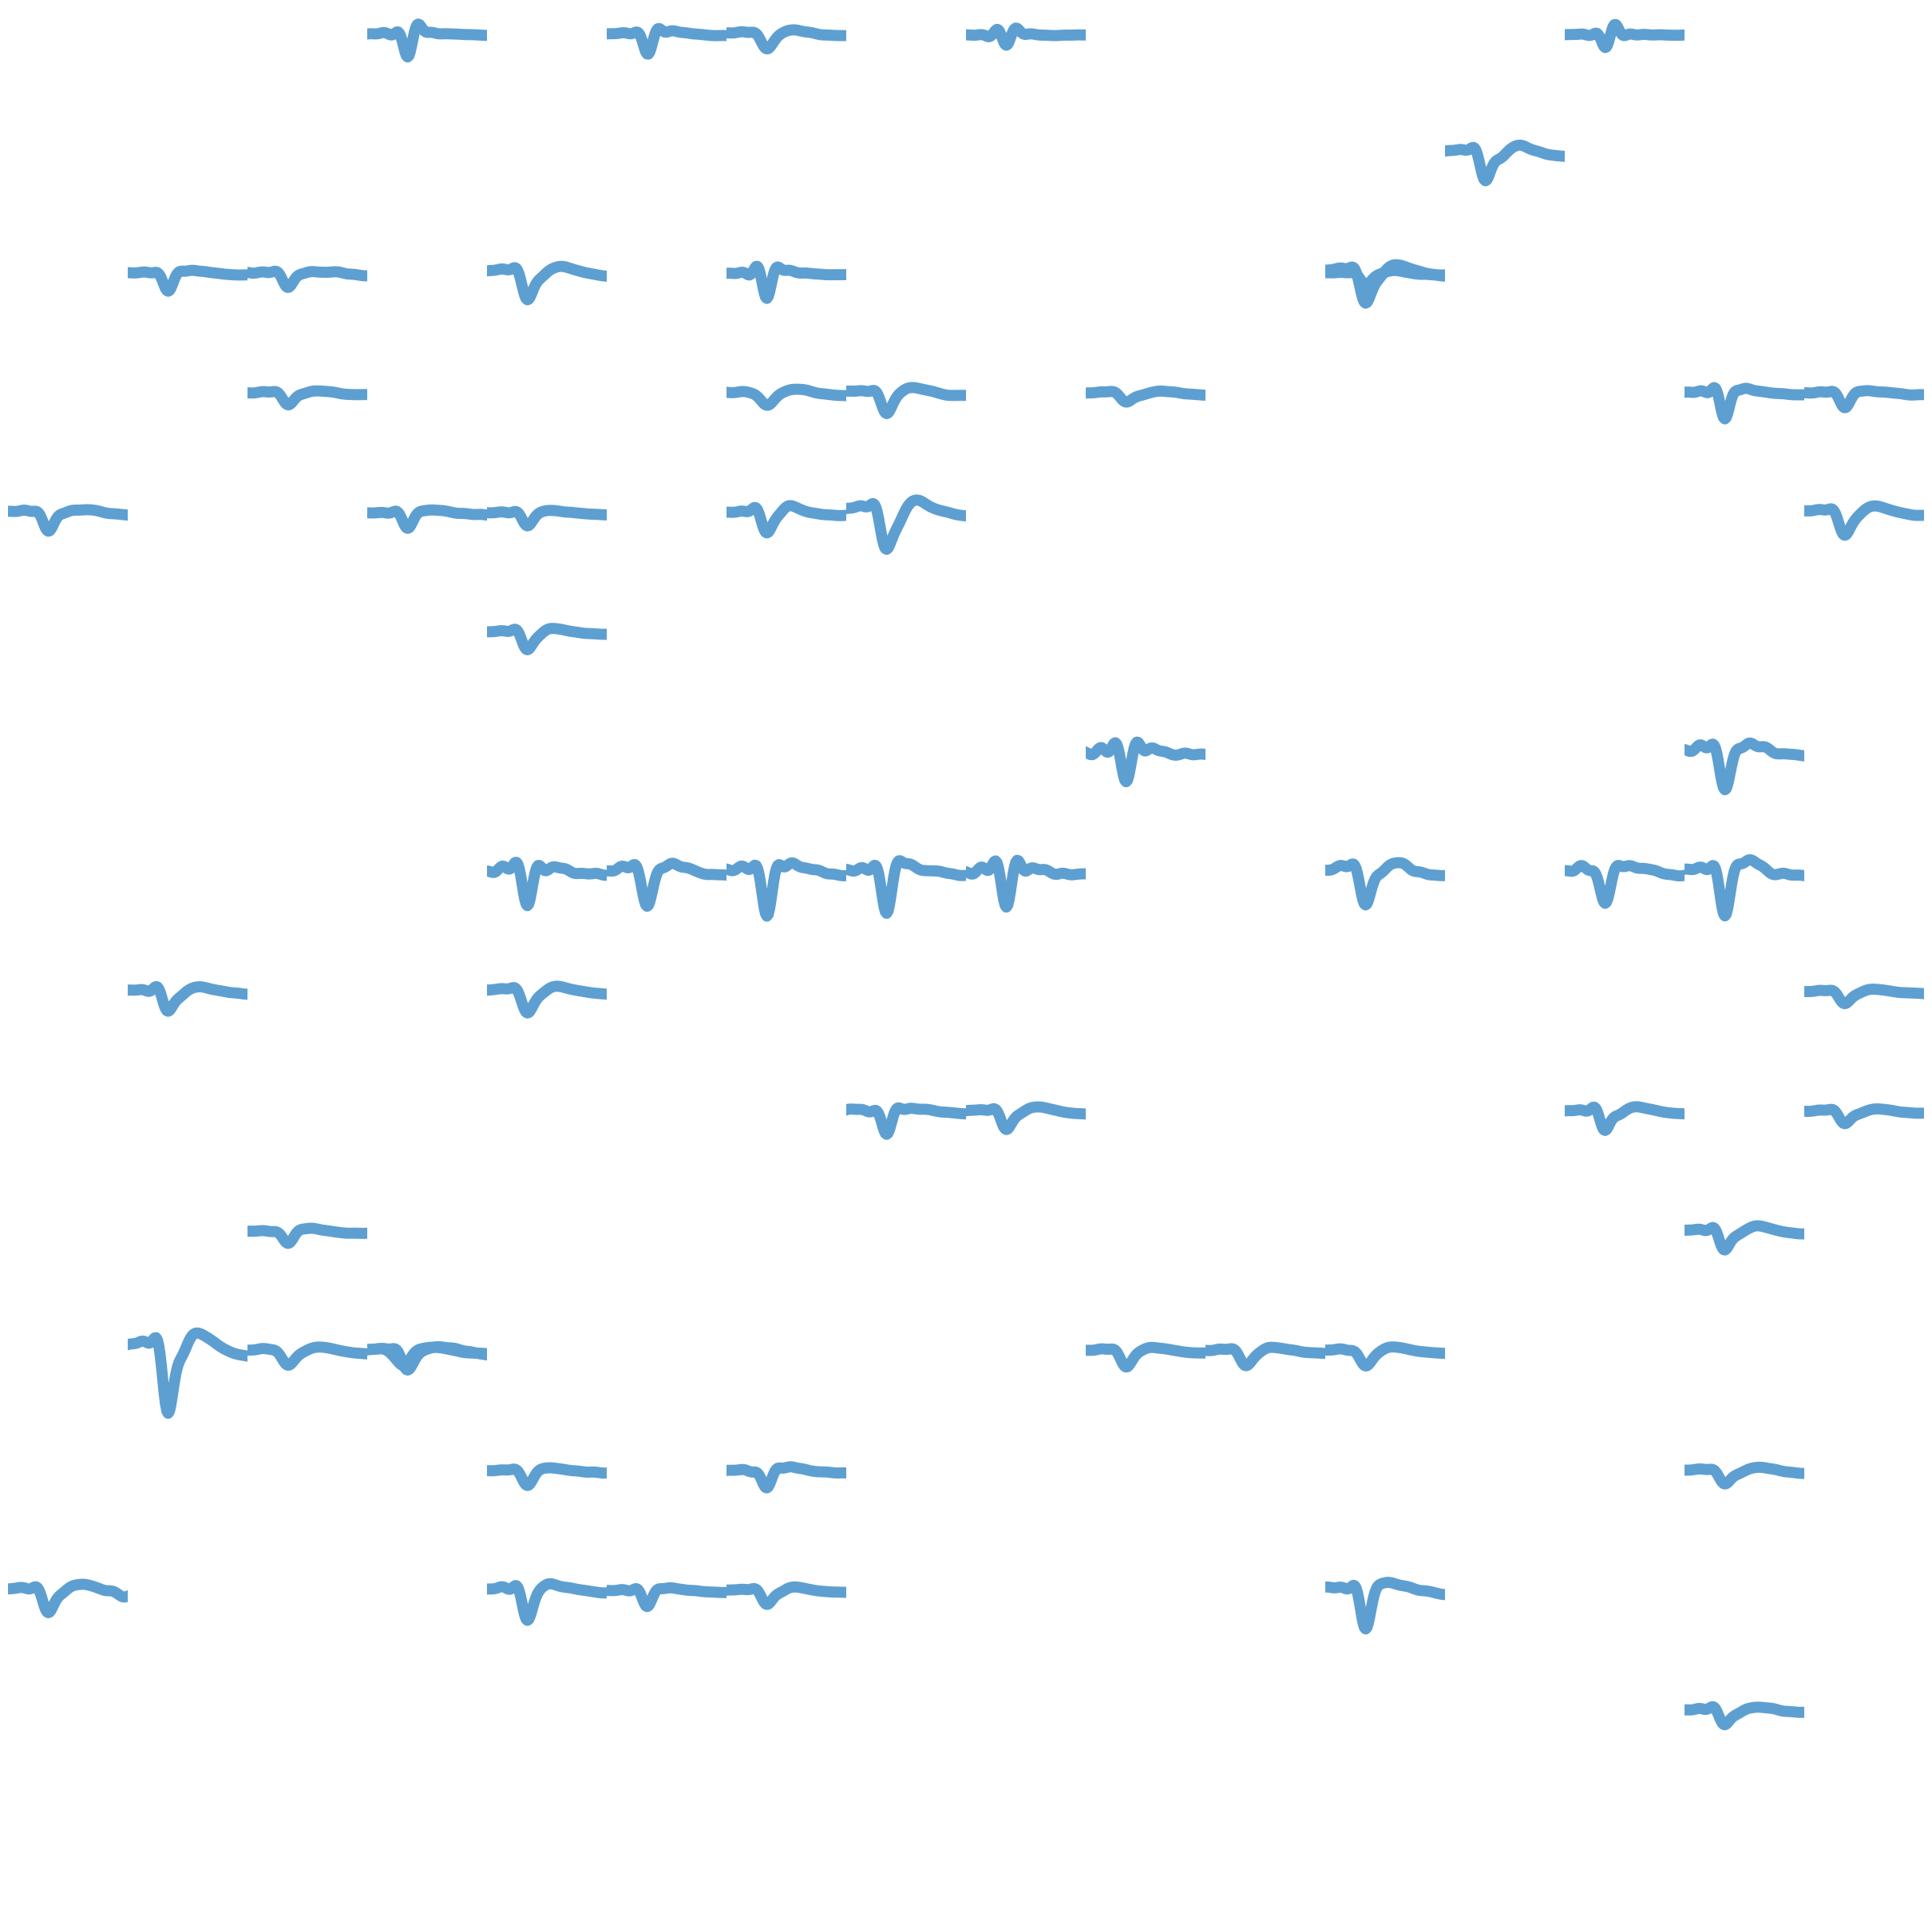

绘制 Session 2 的waveform网格图 (ref=1)...
布局: 16×16 = 256 channels
该session的clusters: 51
已保存: waveform_grid_session_2.pdf


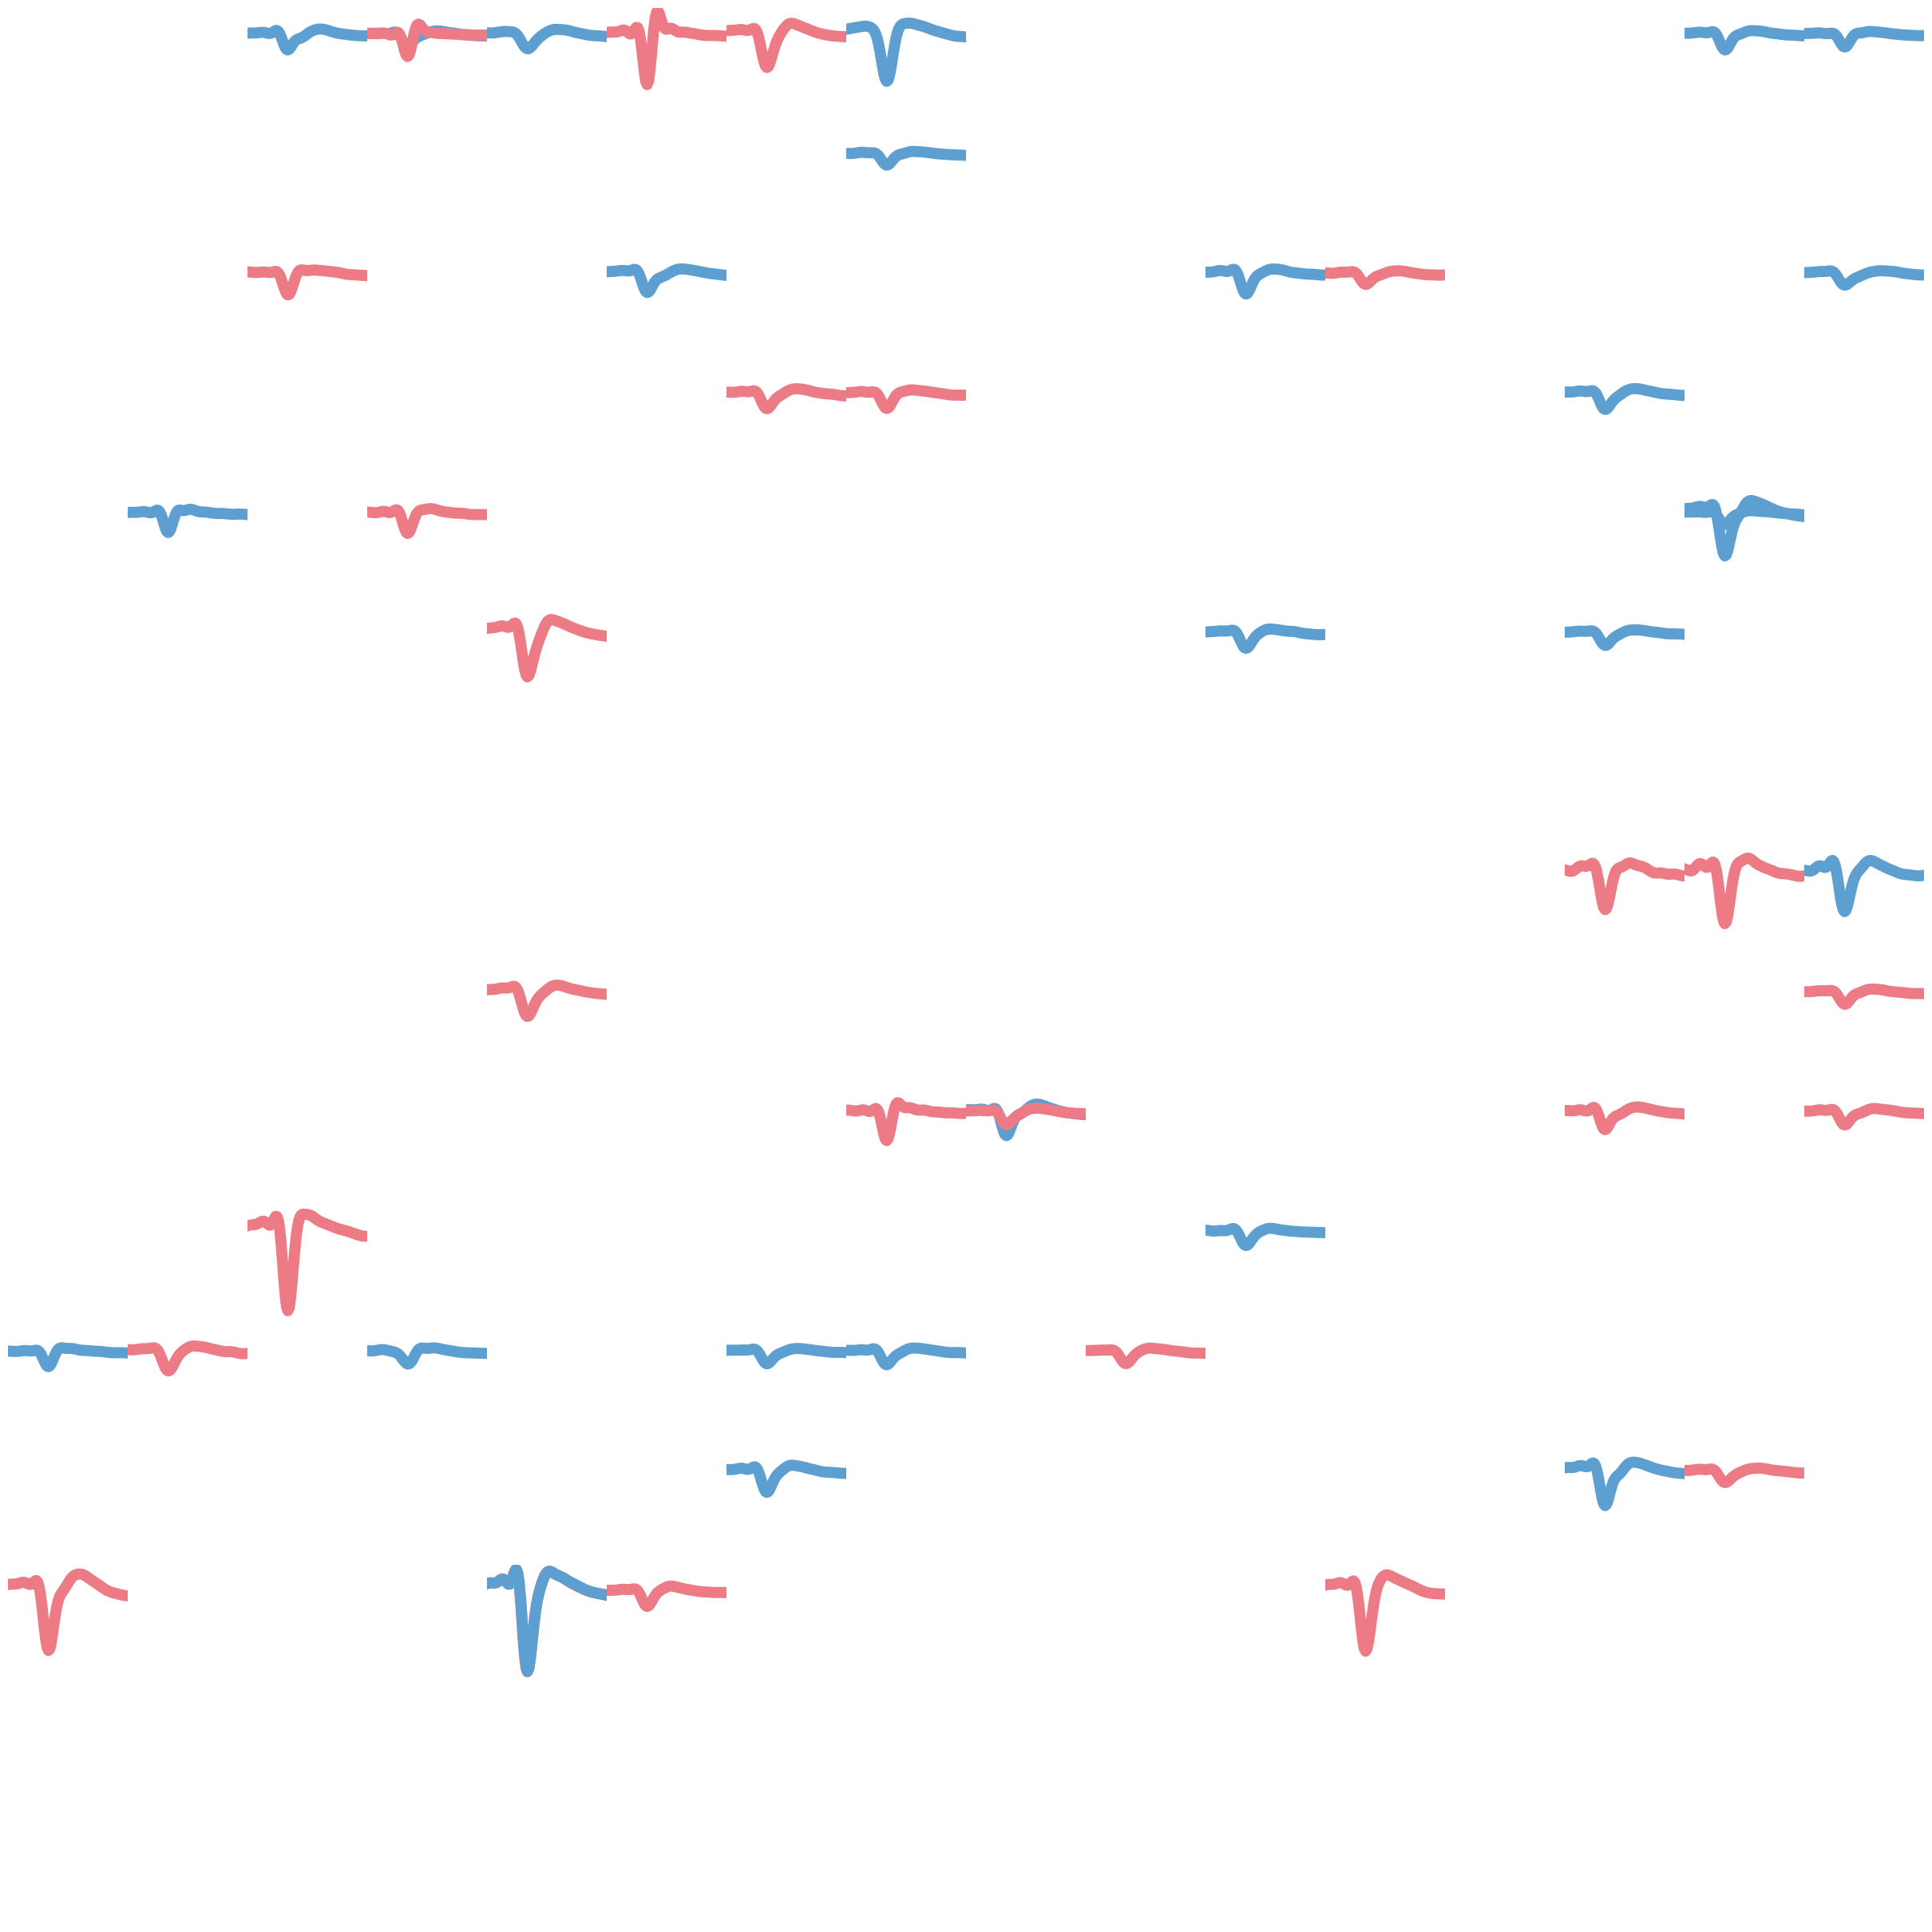

绘制 Session 3 的waveform网格图 (ref=1)...
布局: 16×16 = 256 channels
该session的clusters: 62
已保存: waveform_grid_session_3.pdf


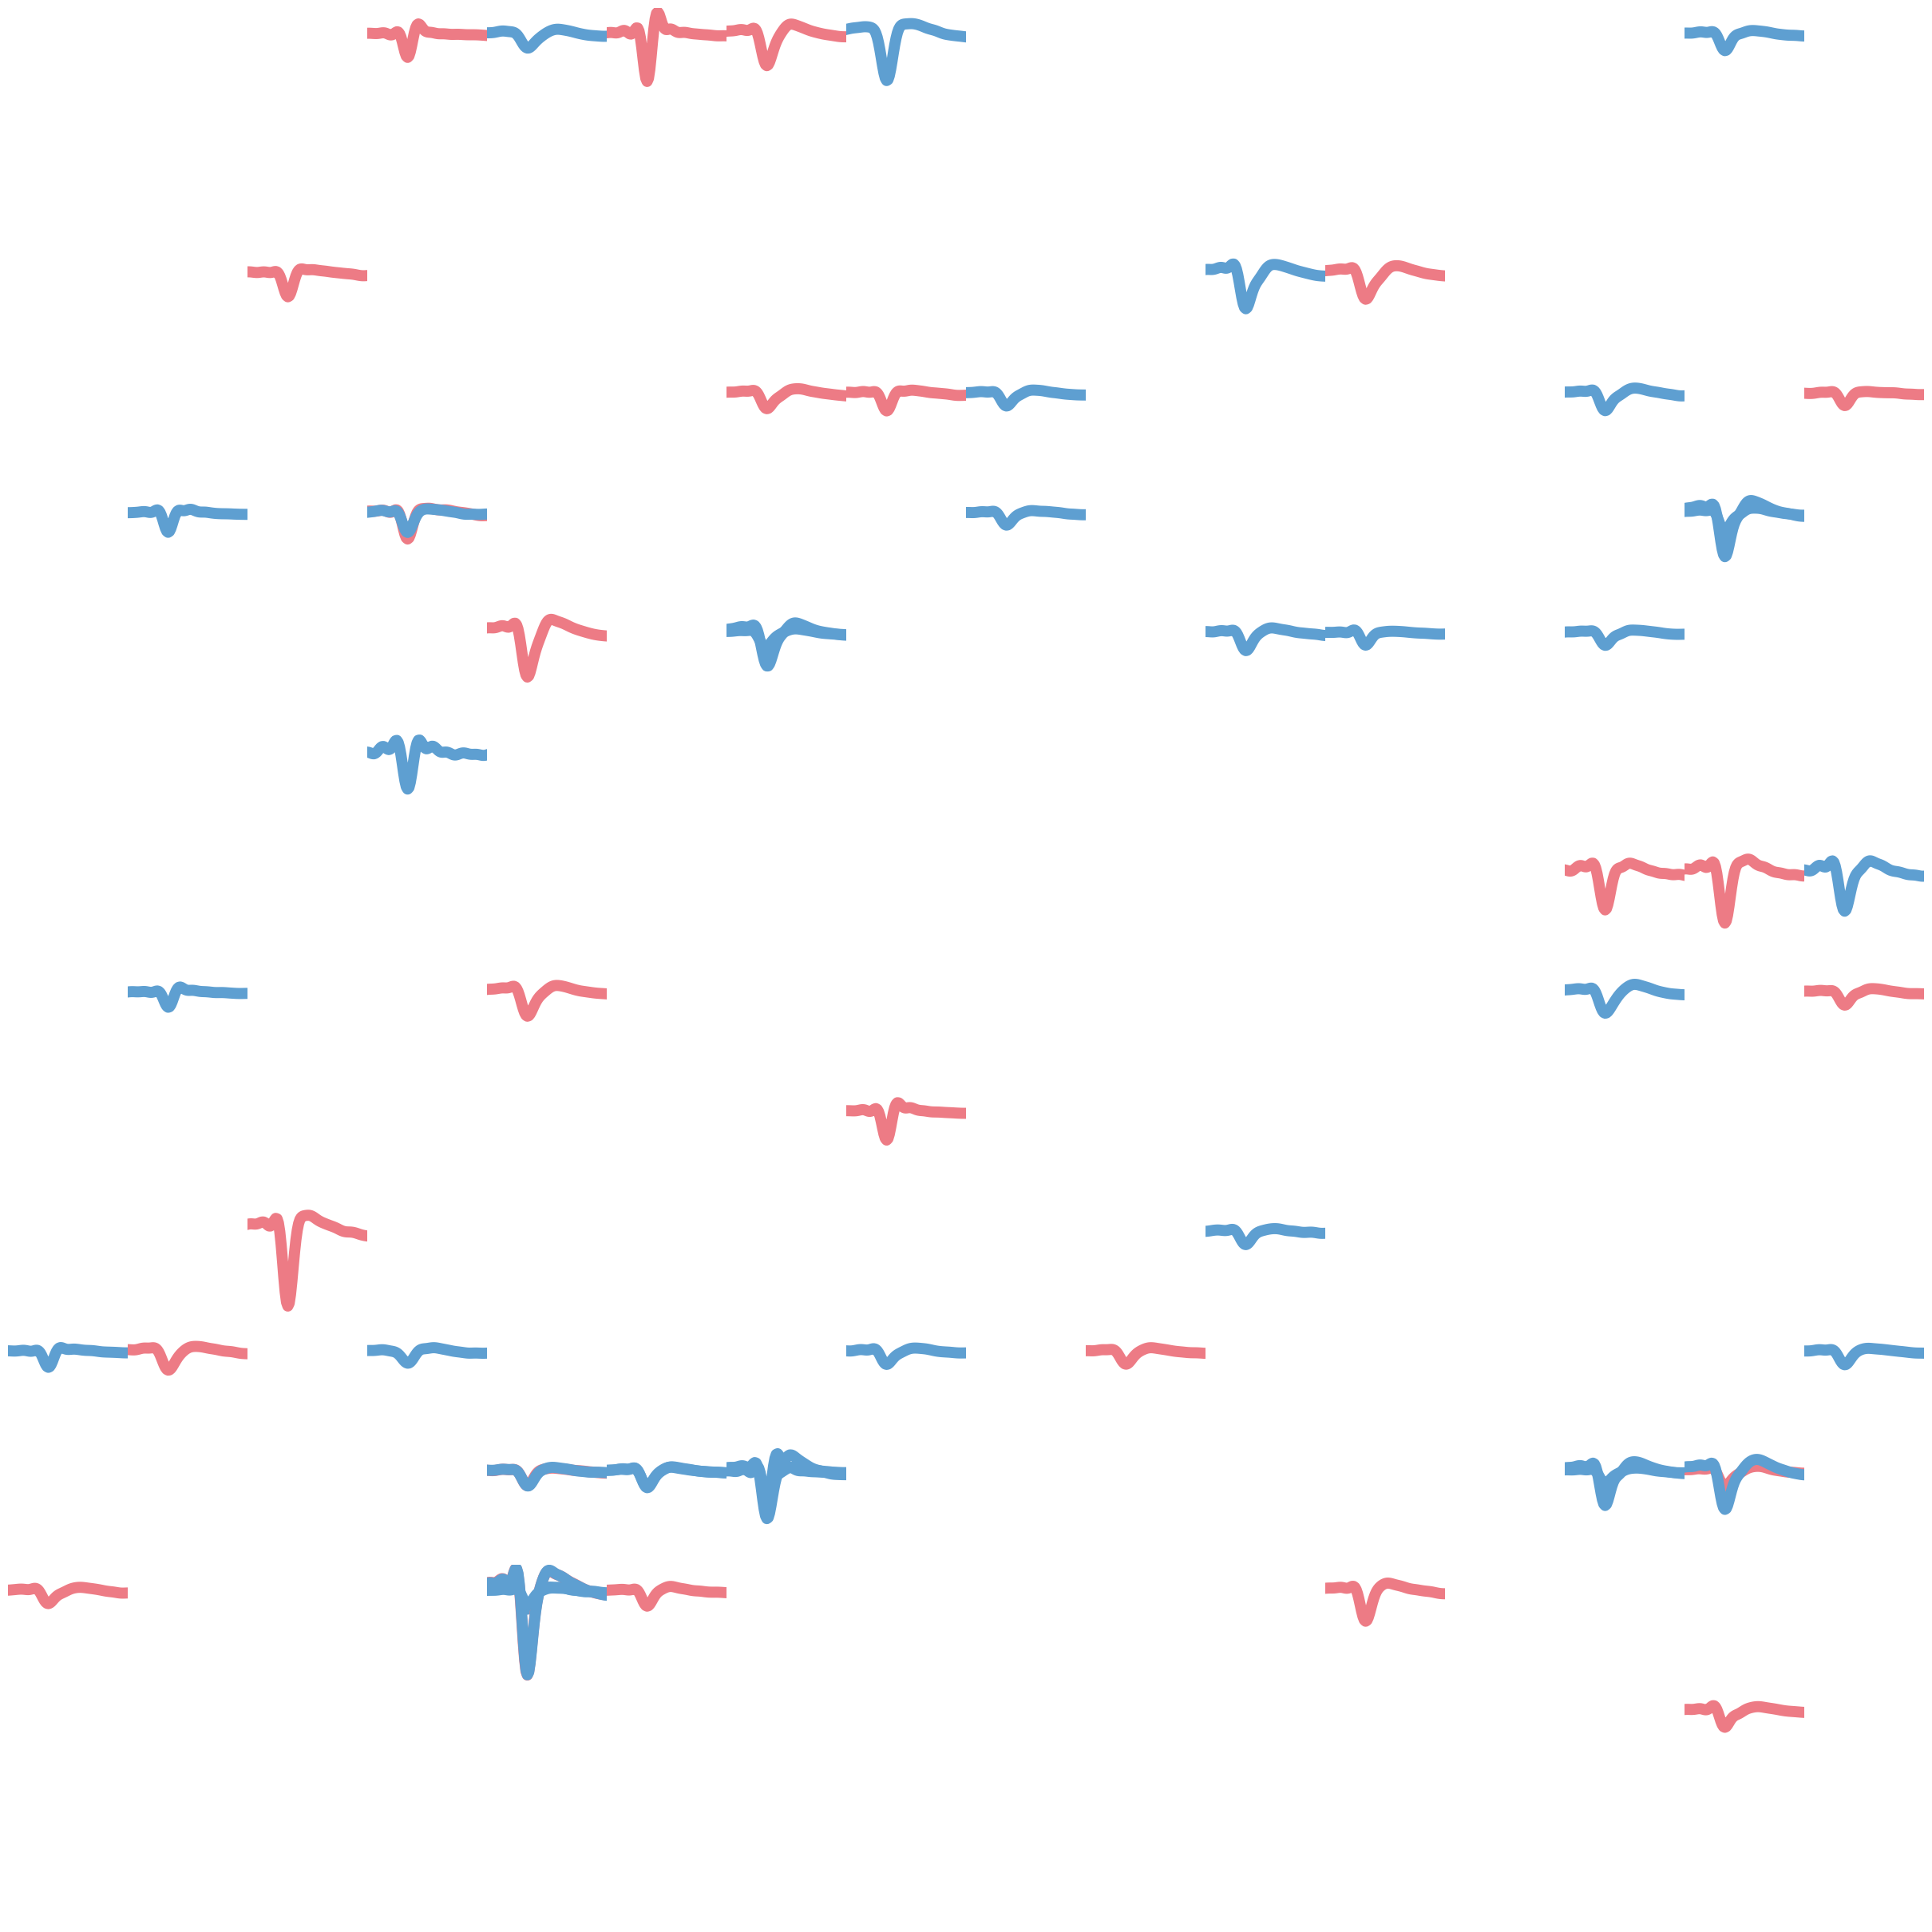

绘制 Session 4 的waveform网格图 (ref=1)...
布局: 16×16 = 256 channels
该session的clusters: 64
已保存: waveform_grid_session_4.pdf


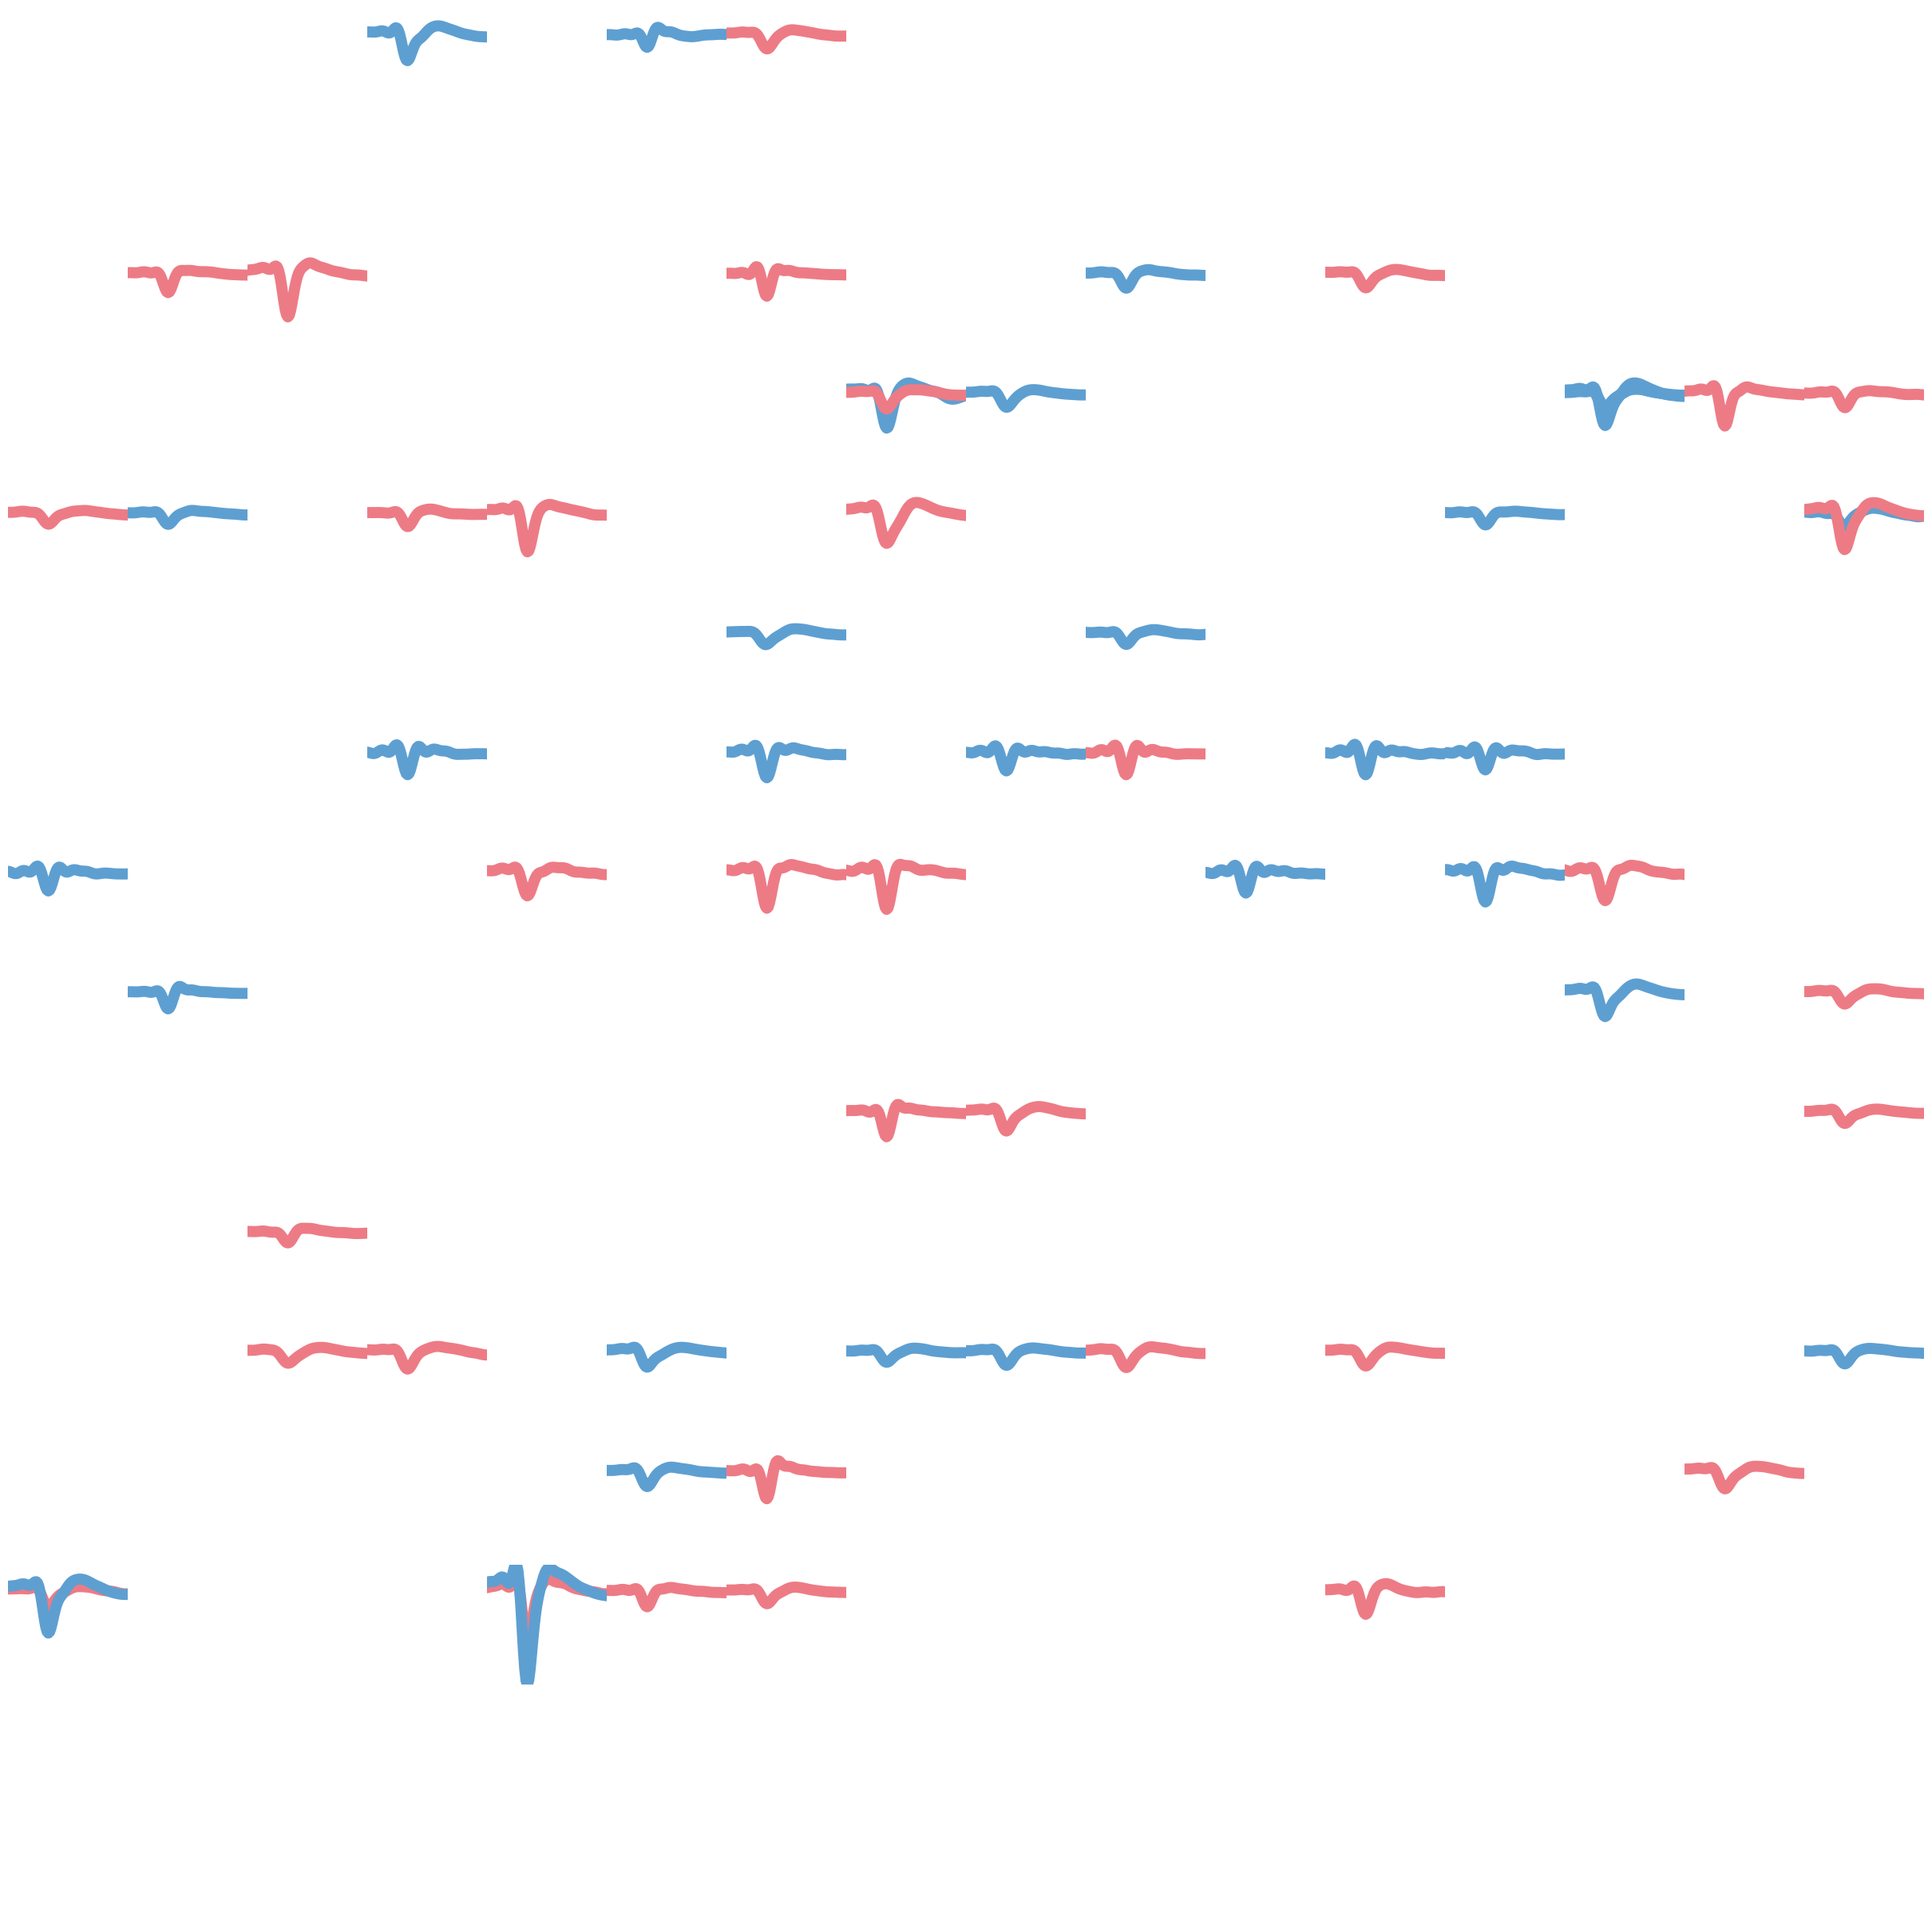

In [12]:
COLOR_REF = '#5E9FD1'
COLOR_MATCH = '#ED7B85'


def compute_global_waveform_ylim(cluster_inf_all):
    waveform_cols = [col for col in cluster_inf_all.columns if col.startswith('mean_waveform_')]
    wf = cluster_inf_all[waveform_cols].to_numpy(dtype=float)
    if np.all(np.isnan(wf)):
        return (-1, 1)
    return (float(np.nanmin(wf)), float(np.nanmax(wf)))


def plot_waveform_grid(cluster_inf_all, session_id, ref_session=1, n_rows=16, n_cols=16, figsize=(24, 24), output_name=None, matched_only=False, global_ylim=None):
    """
    绘制单个session的waveform网格图，16×16布局。
    - 参考session使用 COLOR_REF
    - 其它session：匹配到参考的用 COLOR_MATCH，未匹配也绘制，用 COLOR_REF
    - 所有页共享统一的y轴范围
    """
    df_session = cluster_inf_all[cluster_inf_all['date'] == session_id].copy()
    waveform_cols = [col for col in cluster_inf_all.columns if col.startswith('mean_waveform_')]

    ref_neurons = set(cluster_inf_all[cluster_inf_all['date'] == ref_session]['neuron'].values)
    if matched_only and session_id != ref_session:
        df_session = df_session[df_session['neuron'].isin(ref_neurons)].copy()

    print(f"绘制 Session {session_id} 的waveform网格图 (ref={ref_session})...")
    print(f"布局: {n_rows}×{n_cols} = {n_rows*n_cols} channels")
    print(f"该session的clusters: {len(df_session)}")

    if df_session.empty:
        print(f"Session {session_id} 没有可绘制的cluster")
        return None

    fig = plt.figure(figsize=figsize)
    y_min, y_max = global_ylim if global_ylim else compute_global_waveform_ylim(cluster_inf_all)

    for ch in range(n_rows * n_cols):
        ax = plt.subplot(n_rows, n_cols, ch + 1)
        ch_clusters = df_session[df_session['ch'] == ch]

        if len(ch_clusters) > 0:
            for _, row in ch_clusters.iterrows():
                waveform = row[waveform_cols].values.astype(float)
                if np.isnan(waveform).all():
                    continue
                if session_id == ref_session:
                    color = COLOR_REF
                else:
                    color = COLOR_MATCH if row['neuron'] in ref_neurons else COLOR_REF
                ax.plot(waveform, color=color, linewidth=10, alpha=1)

        ax.axis('off')
        ax.set_xlim(0, len(waveform_cols) - 1)
        ax.set_ylim(y_min, y_max)

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

    if output_name:
        plt.savefig(output_name, dpi=150, bbox_inches='tight')
        print(f"已保存: {output_name}")

    plt.show()
    return fig


global_ylim = compute_global_waveform_ylim(cluster_inf_all)
for session_id in [1, 2, 3, 4]:
    output_name = f"waveform_grid_session_{session_id}.pdf"
    plot_waveform_grid(cluster_inf_all, session_id=session_id, ref_session=1, output_name=output_name, matched_only=False, global_ylim=global_ylim)

